# Can we fit the CFFs using DNNs as predicted by a model?

## (1): Initializing Requisite Code/Settings:

### (1.1): Import Libraries:

In [7]:
import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import iminuit
from iminuit import Minuit
from iminuit.cost import LeastSquares
from scipy.integrate import quad, quad_vec
import gepard as g
from gepard.fits import th_KM09a, th_KM09b, th_KM15

In [4]:
print(f"gepard version: {g.__version__}")
print(f"Tensorflow version: {tf.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"imunuit version: {iminuit.__version__}")

gepard version: 0.9.10
Tensorflow version: 2.16.1
pandas version: 2.2.3
Numpy version: 1.26.4
imunuit version: 2.31.1


### (1.2): Matplotlib Plotting Aesthetics:

In [5]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 8.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['ytick.major.size'] = 8.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.size'] = 2.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.right'] = True

## (2): Generating Pseudodata:

### (2.1): Defining the Kinematic Boundaries:

In [6]:
BEAM_K_LOWER = 5.5
BEAM_K_UPPER = 11.0
Q_SQUARED_LOWER = 1.0
Q_SQUARED_UPPER = 5.0
X_B_LOWER = 0.1
X_B_UPPER = 0.6
T_LOWER = -1.0
T_UPPER = -.1
PHI_LOWER = 0.
PHI_UPPER = 360.

NUMBER_OF_BEAM_K = 6
NUMBER_OF_Q_SQUARED = 10
NUMBER_OF_X_B = 6
NUMBER_OF_T = 6
NUMBER_OF_PHI = 15

K_RANGE = np.linspace(BEAM_K_LOWER, BEAM_K_UPPER, NUMBER_OF_BEAM_K)
Q2_RANGE = np.linspace(Q_SQUARED_LOWER, Q_SQUARED_UPPER, NUMBER_OF_Q_SQUARED)
X_B_RANGE = np.linspace(X_B_LOWER, X_B_UPPER, NUMBER_OF_X_B)
T_RANGE = np.linspace(T_LOWER, T_UPPER, NUMBER_OF_T)
PHI_RANGE = np.linspace(PHI_LOWER, PHI_UPPER, NUMBER_OF_PHI)

### (2.2): Making the Function to Generate Pseudodata:

In [8]:
def generate_kinematic_scan():
    rows = []
    set_counter = 0 
    total_settings = len(K_RANGE) * len(Q2_RANGE) * len(X_B_RANGE) * len(T_RANGE) * len(PHI_RANGE)

    print(f"Iterating over {total_settings} total combinations.")

    for fixed_k in K_RANGE:
        for fixed_q_squared in Q2_RANGE:
            for fixed_x_bjorken in X_B_RANGE:
                for fixed_t in T_RANGE:
                    for fixed_phi in PHI_RANGE:
                        set_counter += 1

                        current_datapoint = g.DataPoint(
                            xB = fixed_x_bjorken, t = fixed_t, Q2 = fixed_q_squared, phi = fixed_phi,
                            process = "ep2epgamma", exptype = 'fixed target',
                            in1energy = fixed_k, in1charge = -1, in1polarization = +1,
                            observable = 'XS',
                            fname = 'Trento')
                        
                        try:

                            # predict the cffs
                            real_h = th_KM15.ReH(current_datapoint)
                            imag_h = th_KM15.ImH(current_datapoint)
                            real_e = th_KM15.ReH(current_datapoint)
                            imag_e = th_KM15.ImH(current_datapoint)
                            real_ht = th_KM15.ReH(current_datapoint)
                            imag_ht = th_KM15.ImH(current_datapoint)
                            real_et = th_KM15.ReH(current_datapoint)
                            imag_et = th_KM15.ImH(current_datapoint)

                            # predict the cross section:
                            km15_cross_section = th_KM15.predict(current_datapoint)

                            if not (np.isfinite(km15_cross_section) and km15_cross_section >= 0 and not np.isnan(km15_cross_section)):
                                raise ValueError("KM15 cross-section was unphysical.")
                            # if not (np.isfinite(bkm10_cross_section) and bkm10_cross_section >= 0 and not np.isnan(bkm10_cross_section)):
                            #     raise ValueError("BKM10 cross-section was unphysical.")

                            rows.append({
                                "set": set_counter,
                                "k": fixed_k,
                                "q_squared": fixed_q_squared,
                                "x_b": fixed_x_bjorken,
                                "t": fixed_t,
                                "phi": fixed_phi,
                                "cross_section": km15_cross_section,
                                "Re[H]": real_h,
                                "Im[H]": imag_h,
                                "Re[E]": real_e,
                                "Im[E]": imag_e,
                                "Re[Ht]": real_ht,
                                "Im[Ht]": imag_ht,
                                "Re[Et]": real_et,
                                "Im[Et]": imag_et,
                            })

                        except Exception:
                            print(f"Unphysical value at: k={fixed_k}, Q^2={fixed_q_squared}, xb={fixed_x_bjorken}, t={fixed_t}, phi={fixed_phi}")

                            continue

                        del current_datapoint
                    
    print(f"Has iteration successfully executed: {set_counter == total_settings}")

    kinematic_grid_data = pd.DataFrame(rows)
    kinematic_grid_data.to_csv("./data/do_not_open_kinematic_scan_v1.csv")
    return kinematic_grid_data

### (2.3): Generate the Pseudodata:
**(WARNING: Running this function requires major computing resources!)**

In [135]:
kinematic_grid_data = generate_kinematic_scan()

Iterating over 32400 total combinations.


C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\kinematics.py:104: RuntimeWarning: divide by zero encountered in scalar divide
  pt.chi0 = sqrt(2.*pt.Q2)*pt.tK/sqrt(1+pt.eps2)/(pt.Q2+pt.t)
C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\kinematics.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  pt.chi = (pt.Q2-pt.t+2.*pt.xB*pt.t)/sqrt(1+pt.eps2)/(pt.Q2+pt.t) - 1.
C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\kinematics.py:99: RuntimeWarning: invalid value encountered in sqrt
  pt.K = sqrt(pt.K2)
C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\kinematics.py:101: RuntimeWarning: invalid value encountered in sqrt
  pt.tK = sqrt(pt.tK2)
C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\kinematics.py:51: RuntimeWarning: invalid value encountered in sqrt
  K = sqrt(K2(Q2, xB, t, y, eps2))
C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\kinematics

Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue wi

C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\bmk.py:1315: RuntimeWarning: invalid value encountered in sqrt
  sqrt(1 - y - (y**2*eps2)/4)*(eps2 +
C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\bmk.py:1667: RuntimeWarning: invalid value encountered in sqrt
  sqrt(1 - y - (y**2*eps2)/4))/(pt.Q2*
C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\bmk.py:1493: RuntimeWarning: invalid value encountered in sqrt
  (8 - 6*xB + 5*eps2)*sqrt(1 - y - (y**2*eps2)/4)*
C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\bmk.py:1327: RuntimeWarning: invalid value encountered in sqrt
  return ( (8*sqrt(2)*sqrt(1 - y - (y**2*eps2)/4)*
C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\bmk.py:1679: RuntimeWarning: invalid value encountered in sqrt
  (16*sqrt(2)*t*xB*sqrt(1 - y - (y**2*eps2)/4)*
C:\Users\fiore\AppData\Roaming\Python\Python312\site-packages\gepard\bmk.py:1506: RuntimeWarning: invalid value e

Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue with kinematics detected!
Issue wi

In [11]:
kinematic_grid_data.nunique()

NameError: name 'kinematic_grid_data' is not defined

In [10]:
print(f"Total of {kinematic_grid_data.nunique()['cross_section']/(NUMBER_OF_BEAM_K*NUMBER_OF_Q_SQUARED*NUMBER_OF_T*NUMBER_OF_X_B*NUMBER_OF_PHI)} physical values.")

NameError: name 'kinematic_grid_data' is not defined

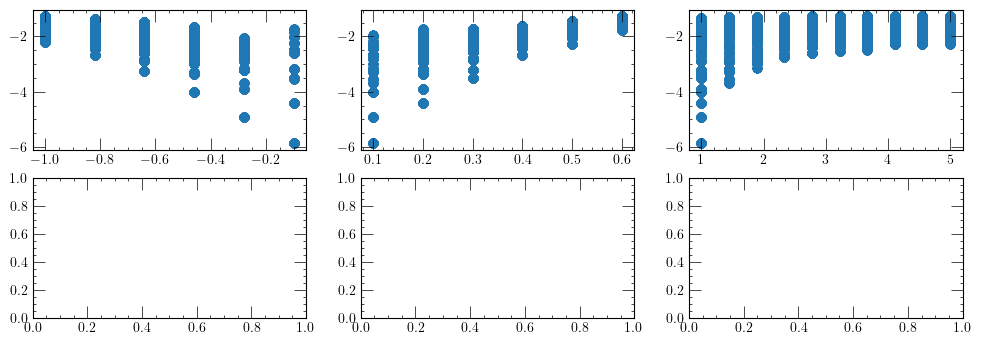

In [137]:
cff_fig, cff_ax = plt.subplots(2, 3, figsize = (12, 4))

cff_ax[0][0].scatter(
    kinematic_grid_data["t"],
    kinematic_grid_data["Re[H]"]
)

cff_ax[0][1].scatter(
    kinematic_grid_data["x_b"],
    kinematic_grid_data["Re[H]"]
)

cff_ax[0][2].scatter(
    kinematic_grid_data["q_squared"],
    kinematic_grid_data["Re[H]"]
)